# Image Clustering

This example shows how SentenceTransformer can be used for Image Clustering.

As model, we use the [OpenAI CLIP Model](https://github.com/openai/CLIP), which was trained on a large set of images and image alt texts.  
Note that the CLIP is now from 2021 and more recent models exist. We use it for this illustration because it is small and therefore run on a Google Colab GPU.  
As an alternative, you can check the models with the [`zero-shot-image-classification`](https://huggingface.co/models?pipeline_tag=zero-shot-image-classification) pipeline tag on the 🤗 Hub.  
You can also test [trimmed](hf.co/blog/introduction-to-trimming) models that have the advantage of being smaller than the models from which they are derived while keeping the same performance. To find these models, we invite you to look at the `visual embedding` models listed in this [Space](https://huggingface.co/spaces/alphaedge-ai/Trimming_models_search).

As a source for fotos, we use the [Unsplash Dataset Lite](https://unsplash.com/data), which contains about 25k images. See the [License](https://unsplash.com/license) about the Unsplash images.

We encode all images into vector space and then find high density regions in this vector space, i.e., regions where the images are fairly similar.

In [1]:
from IPython.display import display

from datasets import load_dataset

from sentence_transformers import SentenceTransformer, util

In [ ]:
# First, we load the respective CLIP model
model = SentenceTransformer("sentence-transformers/clip-ViT-B-32")

In [3]:
# Next, we load the Unsplash Dataset Lite
unsplash = load_dataset("sentence-transformers/unsplash-lite")

# We can see that the dataset contains a column containing the images
# but also a column containing keywords that we will not use here.
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords'],
        num_rows: 24996
    })
})

In [4]:
# Now, we need to compute the embeddings
# The attached function will be required for the following cell
# in the case where precomputed embeddings are not used .
embeddings_name = "embeddings_clip-ViT-B-32"

def embed(batch):
    """
    adds to the dataset a column of embeddings of images calculated with the model
    """
    image = batch["image"]
    return {embeddings_name : model.encode(image, convert_to_tensor=True)}

In [5]:
# Here for the calculation of the embeddings, you have 2 choices:
# 1) `use_precomputed_embeddings = True` and in that case you can
# use embeddings that we have already pre-calculated in order to speed up
# the execution of the notebook.
# 2) `use_precomputed_embeddings = False` and compute the embeddings on the fly.
# Takes about 9 minutes on a Google Colab T4

use_precomputed_embeddings = True

if use_precomputed_embeddings:
    embeddings_ds = load_dataset("sentence-transformers/unsplash-lite", name=embeddings_name, split="train")
    unsplash["train"] = unsplash["train"].add_column(embeddings_name, embeddings_ds[embeddings_name])

else:
    unsplash = unsplash.map(embed,batched=True,batch_size=16)

    # # Uncommented the rest of the else condition if you want to save the embeddings
    # # on the Hub to use `use_precomputed_embeddings = True` in the future

    # # We delete 'image' and 'keywords' so as not to save them as duplicates unnecessarily
    # embeddings_ds = unsplash['train'].remove_columns(['image', 'keywords'])
    # embeddings_ds.push_to_hub(
    #     "your_username/unsplash-lite", # your username
    #     config_name=embeddings_name,
    #     split="train",
    #     token="hf_xx" # your HF token
    # )

# We do have a new column containing our embeddings :D
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords', 'embeddings_clip-ViT-B-32'],
        num_rows: 24996
    })
})

In [6]:
# We have implemented our own, efficient method to find high density regions in vector space
def community_detection(embeddings, threshold, min_community_size=10, init_max_size=1000):
    """
    Function for Fast Community Detection

    Finds in the embeddings all communities, i.e. embeddings that are close (closer than threshold).

    Returns only communities that are larger than min_community_size. The communities are returned
    in decreasing order. The first element in each list is the central point in the community.
    """

    # Compute cosine similarity scores
    cos_scores = util.cos_sim(embeddings, embeddings)

    # Minimum size for a community
    top_k_values, _ = cos_scores.topk(k=min_community_size, largest=True)

    # Filter for rows >= min_threshold
    extracted_communities = []
    for i in range(len(top_k_values)):
        if top_k_values[i][-1] >= threshold:
            new_cluster = []

            # Only check top k most similar entries
            top_val_large, top_idx_large = cos_scores[i].topk(k=init_max_size, largest=True)
            top_idx_large = top_idx_large.tolist()
            top_val_large = top_val_large.tolist()

            if top_val_large[-1] < threshold:
                for idx, val in zip(top_idx_large, top_val_large):
                    if val < threshold:
                        break

                    new_cluster.append(idx)
            else:
                # Iterate over all entries (slow)
                for idx, val in enumerate(cos_scores[i].tolist()):
                    if val >= threshold:
                        new_cluster.append(idx)

            extracted_communities.append(new_cluster)

    # Largest cluster first
    extracted_communities = sorted(extracted_communities, key=lambda x: len(x), reverse=True)

    # Step 2) Remove overlapping communities
    unique_communities = []
    extracted_ids = set()

    for community in extracted_communities:
        add_cluster = True
        for idx in community:
            if idx in extracted_ids:
                add_cluster = False
                break

        if add_cluster:
            unique_communities.append(community)
            for idx in community:
                extracted_ids.add(idx)

    return unique_communities

In [7]:
# Now we run the clustering algorithm
# With the threshold parameter, we define at which threshold we identify two images as similar.
# Set the threshold lower, and you will get larger clusters which have less similar images in it
# (e.g. black cat images vs. cat images vs. animal images).
# With min_community_size, we define that we only want to have clusters of a certain minimal size

# Note: about 2 minutes on a Google Colab T4

img_emb = unsplash["train"][embeddings_name]
clusters = community_detection(img_emb, threshold=0.9, min_community_size=10)
print("Total number of clusters:", len(clusters))

Total number of clusters: 154




Cluster size: 512


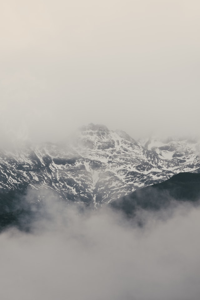

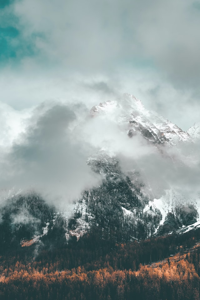

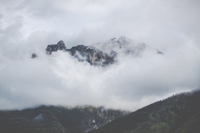



Cluster size: 426


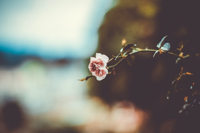

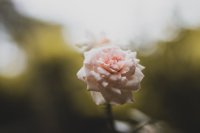

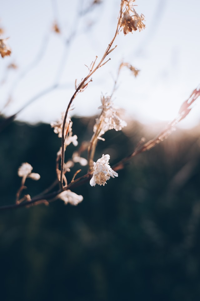



Cluster size: 383


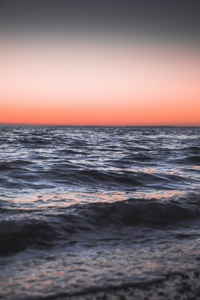

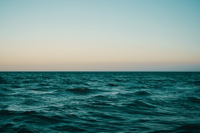

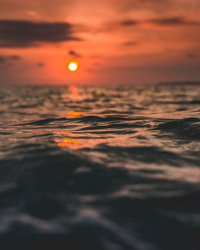



Cluster size: 273


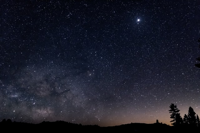

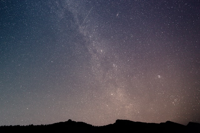

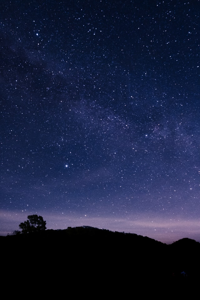



Cluster size: 197


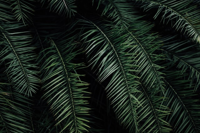

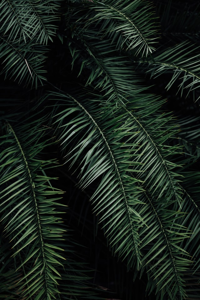

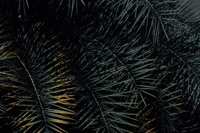



Cluster size: 147


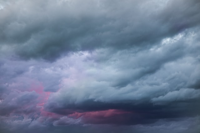

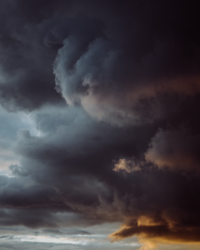

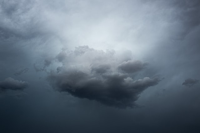



Cluster size: 119


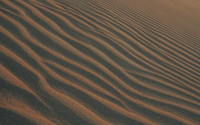

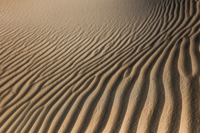

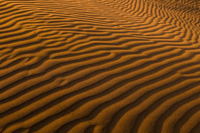



Cluster size: 115


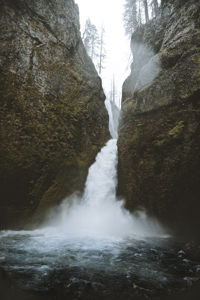

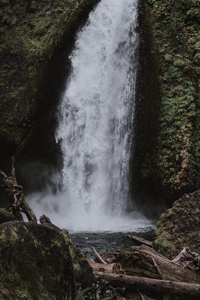

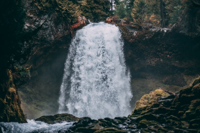



Cluster size: 115


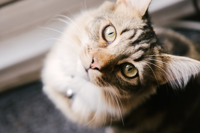

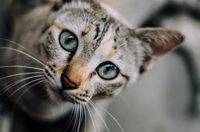

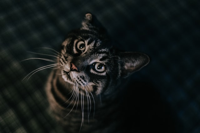



Cluster size: 101


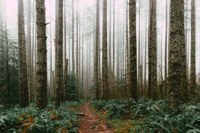

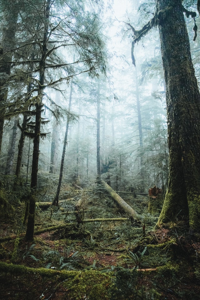

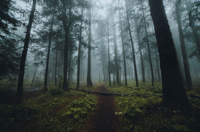

In [8]:
# Now we output the first 10 (largest) clusters
for cluster in clusters[0:10]:
    print("\n\nCluster size:", len(cluster))

    # Output 3 images
    for idx in cluster[0:3]:
        # # original size
        # display(unsplash["train"][idx]["image"])
        
        # # width=200px
        display(unsplash["train"][idx]["image"].resize((200, int(200 * unsplash["train"][idx]["image"].height / unsplash["train"][idx]["image"].width))))